# **Inverse Modeling of Cartesian Model**

In [1]:
%env CUDA_VISIBLE_DEVICES = 0
import torch
import numpy as np
import matplotlib.pyplot as plt
from functools import partial
import sys
sys.path.append("../../../..")
from ConditionalDiffusionGeneration.src.guided_diffusion.unet import create_model, create_DiT_model
from ConditionalDiffusionGeneration.src.guided_diffusion.condition_methods import get_conditioning_method
from ConditionalDiffusionGeneration.src.guided_diffusion.measurements import get_noise, get_operator, retrieve_min_max, norm, unnorm
from ConditionalDiffusionGeneration.src.guided_diffusion.gaussian_diffusion import create_sampler
from einops import rearrange

torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    dev = "cuda"
else:
    dev = "cpu"

device = torch.device(dev)
print(device)

def plot_ksp(k, sat, pre):
    fig, axs = plt.subplots(1, 3, figsize=(7, 2))
    im0 = axs[0].imshow(k, cmap='jet')
    axs[0].set_title('Permeability')
    plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)
    im1 = axs[1].imshow(sat[-1], cmap='jet', vmin=0, vmax=0.6)
    axs[1].set_title('Saturation')
    plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)
    im2 = axs[2].imshow(pre[-1], cmap='jet')
    axs[2].set_title('Pressure')
    plt.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)
    axs[0].axis('off')
    axs[1].axis('off')
    axs[2].axis('off')
    plt.show()

env: CUDA_VISIBLE_DEVICES=0
cuda


In [2]:
u_net_model = create_DiT_model(
                            input_size=64,
                            patch_size=2,
                            in_channels=1,
                            hidden_size=256,
                            depth=12,
                            num_heads=8,
                            mlp_ratio=4.0,
                            class_dropout_prob=0.0,
                            num_classes=None,
                            learn_sigma=True,
                            model_path='/ehome/zhao/DiffNO/UnconditionalDiffusionTraining_and_Generation/output/logs_gaussian_dit/ema_0.9999_160000.pt'
                        )

u_net_model.to(device)
u_net_model.eval()
print('loaded unet (actually DiT) model')

loaded unet (actually DiT) model


>>>>> Loading test data from /ehome/zhao/DiffNO/dataset/Multi_Cartesian_Gaussian.hdf5
Test data loaded, with shape K: (64, 64), Sg: (10, 64, 64), P: (10, 64, 64)


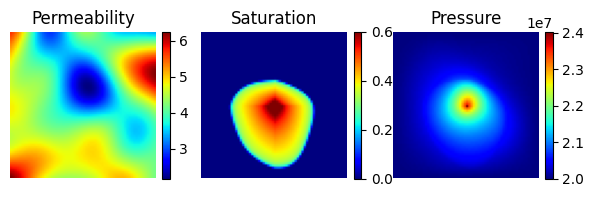

In [3]:
well_num= 1
with_perm = True

operator =  get_operator(name='horizontal_sparse_well',
                        device=device,
                        hdf5_path='/ehome/zhao/DiffNO/dataset/Multi_Cartesian_Gaussian.hdf5',
                        test_idx=144,
                        well_num=well_num,
                        with_perm=with_perm,
                        )
plot_ksp(operator.perm, operator.sat, operator.pre)

In [4]:
noiser = get_noise(sigma=0.0, name='gaussian')
cond_method = get_conditioning_method(operator=operator, noiser=noiser, name='ps_adam', scale=1e-2)
measurement_cond_fn = partial(cond_method.conditioning)

### Sampler

In [5]:
sampler = create_sampler(sampler='ddpm',
                        steps=1000,
                        noise_schedule="cosine",
                        model_mean_type="epsilon",
                        model_var_type="learned_range",
                        dynamic_threshold=False,
                        clip_denoised=True,
                        rescale_timesteps=False,
                        timestep_respacing="")

sample_fn = partial(sampler.p_sample_loop, model=u_net_model, measurement_cond_fn=measurement_cond_fn)

In [6]:
no_of_samples = 5
image_size = 64

x_start = torch.randn(no_of_samples, 1, image_size, image_size, device=device)
measurement_ref = operator.measurement()
samples = [sample_fn(x_start=x_start[i:i+1], measurement=measurement_ref, record=False, save_root=None) for i in range(x_start.shape[0])]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
gen = torch.cat(samples)
gen = unnorm(gen, retrieve_min_max('perm')[0], retrieve_min_max('perm')[1])
gen = gen[:, 0]
print(f"Generated images shape: {gen.shape}") 
torch.save(gen, f'conditional_outputs/pts/sparse_well_of_{well_num}_with_perm.pt')

Generated images shape: torch.Size([20, 64, 64])


### ***Load pt records (CNF out & reference)***

In [4]:
def retrieve_all(num_well, wo_perm):
    if wo_perm:
        gene = torch.load(f'conditional_outputs/pts/sparse_well_of_{num_well}_with_perm.pt', map_location='cpu').detach().numpy()
    else:
        gene = torch.load(f'conditional_outputs/pts/sparse_well_of_{num_well}.pt', map_location='cpu').detach().numpy()
    print(f"Retrieved generated perms shape: {gene.shape}")
    return gene
ref = operator.retrieve_reference()
ref_k = ref['perm']
ref_pre = ref['pre']
ref_sat = ref['sat']
print(f"Reference K shape: {ref_k.shape}, Reference P/Sg shape: {ref_pre.shape}/{ref_sat.shape}")

gene_k_1 = retrieve_all(num_well=1, wo_perm=False)
gene_k_1_with_perm = retrieve_all(num_well=1, wo_perm=True)
gene_k_4 = retrieve_all(num_well=4, wo_perm=False)
gene_k_4_with_perm = retrieve_all(num_well=4, wo_perm=True)
gene_k_8 = retrieve_all(num_well=8, wo_perm=False)
gene_k_8_with_perm = retrieve_all(num_well=8, wo_perm=True)

Retrieving reference:
perm: shape (64, 64)
sat: shape (10, 64, 64)
pre: shape (10, 64, 64)
Reference K shape: (64, 64), Reference P/Sg shape: (10, 64, 64)/(10, 64, 64)
Retrieved generated perms shape: (20, 64, 64)
Retrieved generated perms shape: (20, 64, 64)
Retrieved generated perms shape: (20, 64, 64)
Retrieved generated perms shape: (20, 64, 64)
Retrieved generated perms shape: (20, 64, 64)
Retrieved generated perms shape: (20, 64, 64)


In [5]:
from Surrogate.ufno import Net3d

def ufno_pred(k):
    if not isinstance(k, torch.Tensor):
        k = torch.tensor(k, dtype=torch.float32).to(device)
    k = norm(k, retrieve_min_max('perm')[0], retrieve_min_max('perm')[1]).unsqueeze(1)
    print(f'input k shape: {k.shape}')
    
    tn = [1., 6., 12., 24., 36., 60., 7*12., 10*12., 15*12, 20*12]  # 10 time steps in months
    ts = [t*86400*30 for t in tn]
    normed_ts = norm(np.array(ts), retrieve_min_max('ts')[0], retrieve_min_max('ts')[1])
    normed_ts = np.tile(normed_ts[:, None, None], (1, 64, 64))    # <1, 64, 64>
    normed_ts = torch.tensor(normed_ts, dtype=torch.float32).to(device)
    
    batch_size = k.shape[0]
    ts_expand = normed_ts.expand(batch_size, -1, -1, -1)
    k_expand = k.expand(-1, ts_expand.size(1), -1, -1)
    assert ts_expand.shape == k_expand.shape, f"UFNO input shapes mismatch: {ts_expand.shape}, {k_expand.shape}"
    
    x_surrogate = torch.stack((k_expand, ts_expand), dim=-1)    # <b, t, 64, 64, c=2>
    x_surrogate = rearrange(x_surrogate, 'b t h w c -> b h w t c')
    print(f'UFNO input shape: {x_surrogate.shape}')
    
    sg_ufno = Net3d(modes1=10, modes2=10, modes3=8, width=36).to(device)
    p_ufno = Net3d(modes1=10, modes2=10, modes3=8, width=36).to(device)
    sg_ufno.load_state_dict(torch.load('/ehome/zhao/DiffNO/checkpoint/ufno_sat.pth')['model_state_dict'])
    p_ufno.load_state_dict(torch.load('/ehome/zhao/DiffNO/checkpoint/ufno_pre.pth')['model_state_dict'])
    sg_ufno.eval()
    p_ufno.eval()
    
    pred_sg = sg_ufno(x_surrogate)
    pred_p = p_ufno(x_surrogate)
    
    if len(pred_sg.shape) < 4:
        pred_sg = pred_sg.unsqueeze(0)
    if len(pred_p.shape) < 4:
        pred_p = pred_p.unsqueeze(0)
    
    pred_sg = rearrange(pred_sg, 'b h w t -> b t h w')
    pred_p = rearrange(pred_p, 'b h w t -> b t h w')
    
    pred_sg = unnorm(pred_sg, retrieve_min_max('sat')[0], retrieve_min_max('sat')[1])
    pred_p = unnorm(pred_p, retrieve_min_max('pre')[0], retrieve_min_max('pre')[1])
    
    print(f'UFNO output shapes: sg {pred_sg.shape}, p {pred_p.shape}')
    return pred_sg.detach().cpu().numpy(), pred_p.detach().cpu().numpy()

ufno_sat_1, ufno_pre_1 = ufno_pred(gene_k_1)
ufno_sat_1_with_perm, ufno_pre_1_with_perm = ufno_pred(gene_k_1_with_perm)
ufno_sat_4, ufno_pre_4 = ufno_pred(gene_k_4)
ufno_sat_4_with_perm, ufno_pre_4_with_perm = ufno_pred(gene_k_4_with_perm)
ufno_sat_8, ufno_pre_8 = ufno_pred(gene_k_8)
ufno_sat_8_with_perm, ufno_pre_8_with_perm = ufno_pred(gene_k_8_with_perm)

input k shape: torch.Size([20, 1, 64, 64])
UFNO input shape: torch.Size([20, 64, 64, 10, 2])
UFNO output shapes: sg torch.Size([20, 10, 64, 64]), p torch.Size([20, 10, 64, 64])
input k shape: torch.Size([20, 1, 64, 64])
UFNO input shape: torch.Size([20, 64, 64, 10, 2])
UFNO output shapes: sg torch.Size([20, 10, 64, 64]), p torch.Size([20, 10, 64, 64])
input k shape: torch.Size([20, 1, 64, 64])
UFNO input shape: torch.Size([20, 64, 64, 10, 2])
UFNO output shapes: sg torch.Size([20, 10, 64, 64]), p torch.Size([20, 10, 64, 64])
input k shape: torch.Size([20, 1, 64, 64])
UFNO input shape: torch.Size([20, 64, 64, 10, 2])
UFNO output shapes: sg torch.Size([20, 10, 64, 64]), p torch.Size([20, 10, 64, 64])
input k shape: torch.Size([20, 1, 64, 64])
UFNO input shape: torch.Size([20, 64, 64, 10, 2])
UFNO output shapes: sg torch.Size([20, 10, 64, 64]), p torch.Size([20, 10, 64, 64])
input k shape: torch.Size([20, 1, 64, 64])
UFNO input shape: torch.Size([20, 64, 64, 10, 2])
UFNO output shapes: sg

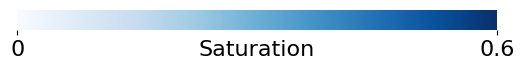

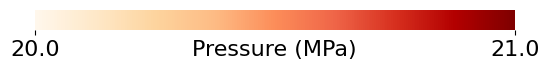

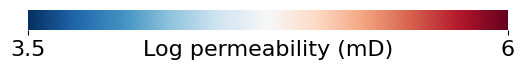

In [150]:
import matplotlib.colors as colors

def plot_colorbar(cmap_name, vmin, vmax, cbar_name, direction='horizontal'):
    cmap = plt.get_cmap(cmap_name)
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    
    if direction == 'horizontal':
        fig = plt.figure(figsize=(6, 2))
        cbar_ax = fig.add_axes([0.2, 0.5, 0.8, 0.1])
        cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
        cbar.set_ticks([vmin, vmax])
        cbar.ax.set_xticklabels([str(vmin), str(vmax)])
        cbar.outline.set_visible(False)
        cbar.ax.tick_params(labelsize=16)
        cbar_ax.text(0.5, -1.0, f"{cbar_name}", transform=cbar_ax.transAxes,
                fontsize=16, ha='center', va='center')
        plt.savefig(f"conditional_outputs/figs/superresolution_colorbar_{cbar_name}.pdf", bbox_inches='tight')
    elif direction == 'vertical':
        fig = plt.figure(figsize=(2, 6))
        cbar_ax = fig.add_axes([0.5, 0.2, 0.1, 0.8])
        cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
        cbar.set_ticks([vmin, vmax])
        cbar.ax.set_yticklabels([str(vmin), str(vmax)])
        cbar.outline.set_visible(False)
        cbar.ax.tick_params(labelsize=16)
        cbar_ax.text(2, 0.5, f"{cbar_name}", transform=cbar_ax.transAxes,
                fontsize=16, ha='center', va='center', rotation='vertical')
        plt.savefig(f"conditional_outputs/figs/superresolution_colorbar_{cbar_name}.pdf", bbox_inches='tight')

plot_colorbar('Blues', 0, 0.6, 'Saturation', 'horizontal')
plot_colorbar('OrRd', 20., 21., 'Pressure (MPa)', 'horizontal')
plot_colorbar('RdBu_r', 3.5, 6, 'Log permeability (mD)', 'horizontal')

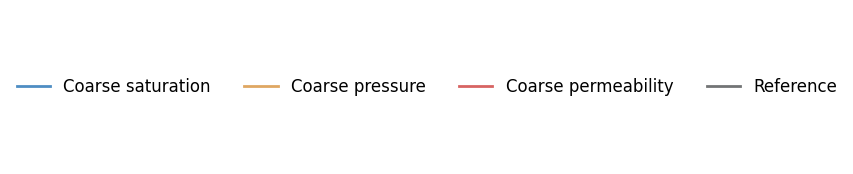

In [48]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(4, 2))
custom_lines = [
    Line2D([0], [0], color='#4e8dc3', lw=2),
    Line2D([0], [0], color='#dfa762', lw=2),
    Line2D([0], [0], color='#d76462', lw=2),
    Line2D([0], [0], color='#727475', lw=2),
]
legend = ax.legend(custom_lines, ['Coarse saturation', 'Coarse pressure', 'Coarse permeability', 'Reference'], 
                   loc='center', ncol=4, frameon=False, fontsize=12)
ax.axis('off')  # 不显示坐标轴
# plt.tight_layout()
plt.savefig('conditional_outputs/figs/superresolution_line_lengends.pdf', bbox_inches='tight')
plt.show()

### Overall evaluation

(64, 64) (20, 10, 64, 64) (20, 10, 64, 64)


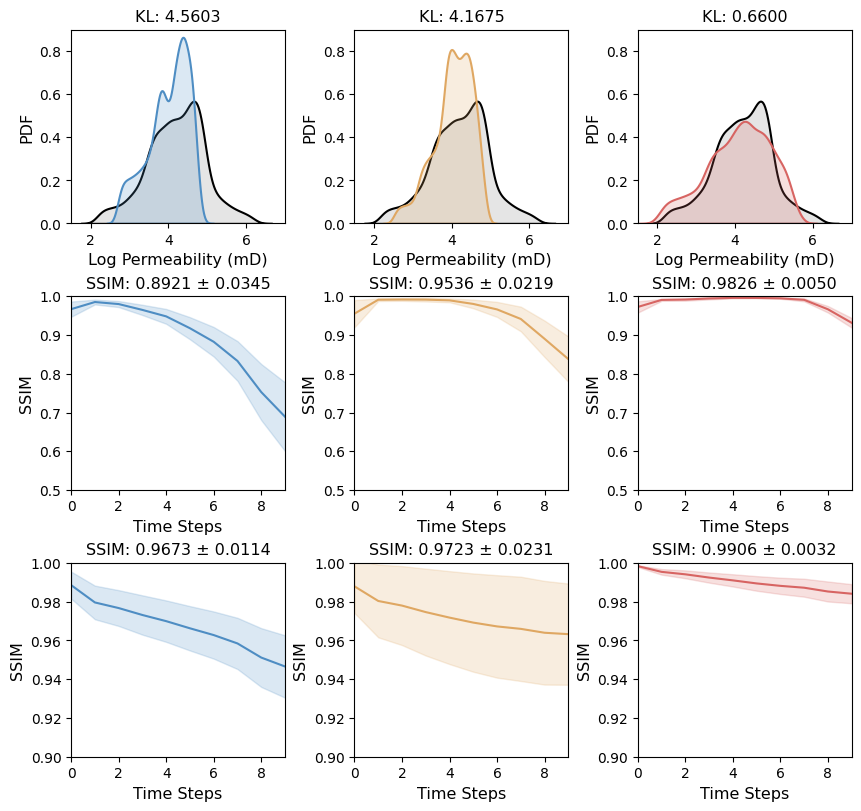

In [15]:
import numpy as np
from scipy.special import rel_entr  # elementwise p*log(p/q)
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.metrics import structural_similarity as ssim

def kl_ref_pred(field_ref, field_pred, bins=100, eps=1e-12, clip_percentile=(0.1, 99.9)):
    """
    估计 D_KL(P_ref || Q_pred)，用共享直方图估计两分布的边缘密度。
    - bins: 分箱数
    - eps: 频数平滑，避免 0
    - clip_percentile: 共享取值范围的稳健截断，减少尾部空箱
    - plot: 是否画对比直方图
    """
    x_ref = np.asarray(field_ref).ravel()
    x_pred = np.asarray(field_pred).ravel()

    lo = np.percentile(np.concatenate([x_ref, x_pred]), clip_percentile[0])
    hi = np.percentile(np.concatenate([x_ref, x_pred]), clip_percentile[1])

    p_hist, bin_edges = np.histogram(x_ref, bins=bins, range=(lo, hi), density=True)
    q_hist, _         = np.histogram(x_pred, bins=bin_edges, density=True)

    p = p_hist + eps
    q = q_hist + eps
    p /= p.sum()
    q /= q.sum()

    kl = float(np.sum(rel_entr(p, q)))

    return kl

def plot_hist(field_ref, field_pred, axs_toplot, color, fontsize):
    field_ref = np.asarray(field_ref).ravel()
    field_pred = np.asarray(field_pred).ravel()
    sns.kdeplot(x=field_ref, fill=True, ax=axs_toplot, color='black', alpha=0.1, linewidth=1.5,)
    sns.kdeplot(x=field_pred, fill=True, ax=axs_toplot, color=color, alpha=0.2, linewidth=1.5,)
    axs_toplot.set_title(f'KL: {kl_ref_pred(field_ref, field_pred):.4f}', fontsize=fontsize)
    axs_toplot.set_xlabel('Log Permeability (mD)', fontsize=fontsize)
    axs_toplot.set_ylabel('PDF', fontsize=fontsize)
    axs_toplot.set_xlim(1.5, 7)
    axs_toplot.set_ylim(0, 0.9)


def compute_temporal_ssim(field_ref, field_pred):
    ssim_values = []
    for i in range(field_pred.shape[0]):
        ssim_t_values = []
        for t in range(field_pred.shape[1]):
            ssim_value = ssim(field_ref[t, :, :], field_pred[i, t, :, :], data_range=field_ref[t, :, :].max() - field_ref[t, :, :].min())
            ssim_t_values.append(ssim_value)
        ssim_values.append(np.array(ssim_t_values))
    return np.array(ssim_values)  # shape (num_samples, time_steps)

def plot_ssim(field_ref, field_pred, axs_toplot, color, fontsize, y_bot=0.75):
    ssim_values = compute_temporal_ssim(field_ref, field_pred)
    mean_ssim = np.mean(ssim_values, axis=0)
    std_ssim = np.std(ssim_values, axis=0)
    x = np.arange(field_ref.shape[0])
    axs_toplot.plot(x, mean_ssim, color=color, linewidth=1.5)
    axs_toplot.fill_between(x, mean_ssim - std_ssim, mean_ssim + std_ssim, color=color, alpha=0.2)
    axs_toplot.set_title(f'SSIM: {mean_ssim.mean():.4f} ± {std_ssim.mean():.4f}', fontsize=fontsize)
    axs_toplot.set_ylim(y_bot, 1)
    axs_toplot.set_xlabel('Time Steps', fontsize=fontsize)
    axs_toplot.set_ylabel('SSIM', fontsize=fontsize)
    # axs_toplot.axvline(x=4, color='gray', linewidth=1, ls='-')
    axs_toplot.set_xlim(0, field_ref.shape[0]-1)


cc_list = ['#4e8dc3', '#dfa762', '#d76462']
kk_list = [gene_k_1.mean(axis=0), gene_k_4.mean(axis=0), gene_k_8.mean(axis=0)]
ss_list = [ufno_sat_1, ufno_sat_4, ufno_sat_8]
pp_list = [ufno_pre_1, ufno_pre_4, ufno_pre_8]
print(kk_list[0].shape, ss_list[0].shape, pp_list[0].shape)


def plot_all(reference_k, reference_sat, reference_pre, k_genes, s_genes, p_genes, color_toplot):
    fig, axs = plt.subplots(3, 3, figsize=(8.5, 8), constrained_layout=True)
    axis_fontsize = 11.5
    
    for i in range(3):
        plot_hist(reference_k, k_genes[i], axs[0, i], color_toplot[i], axis_fontsize)
        plot_ssim(reference_sat, s_genes[i], axs[1, i], color_toplot[i], axis_fontsize, y_bot=0.5)
        plot_ssim(reference_pre, p_genes[i], axs[2, i], color_toplot[i], axis_fontsize, y_bot=0.9)
    
    return fig


plot_all(ref_k, ref_sat, ref_pre, kk_list, ss_list, pp_list, cc_list)
plt.savefig("conditional_outputs/figs_sp/overall_eva_without_perm.pdf", bbox_inches='tight')

(64, 64) (20, 10, 64, 64) (20, 10, 64, 64)


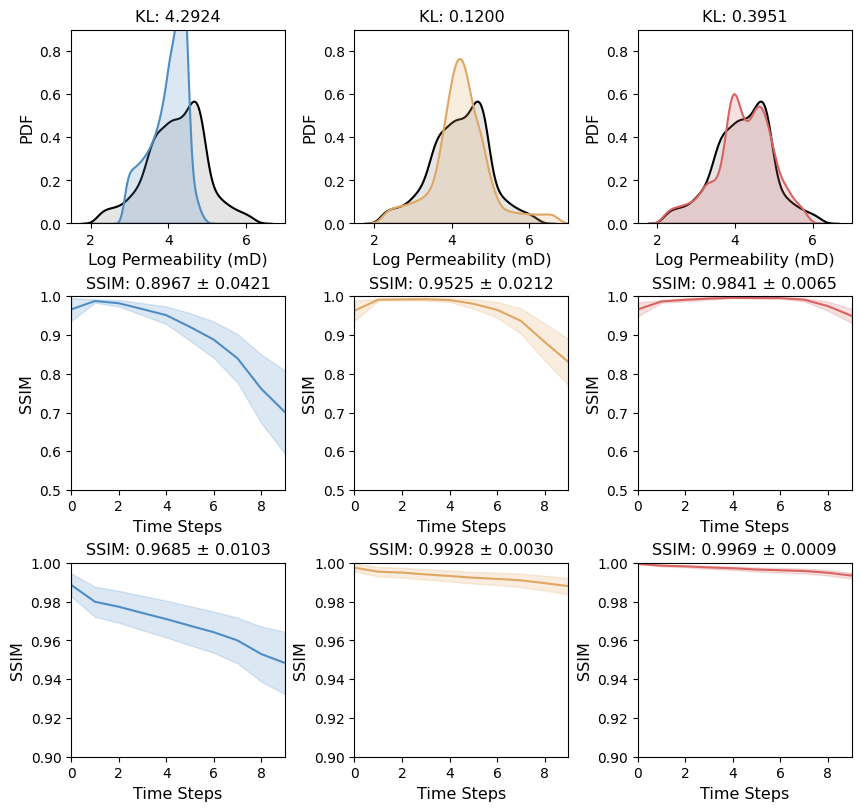

In [16]:
cc_list = ['#4e8dc3', '#dfa762', '#d76462']
kk_list = [gene_k_1_with_perm.mean(axis=0), gene_k_4_with_perm.mean(axis=0), gene_k_8_with_perm.mean(axis=0)]
ss_list = [ufno_sat_1_with_perm, ufno_sat_4_with_perm, ufno_sat_8_with_perm]
pp_list = [ufno_pre_1_with_perm, ufno_pre_4_with_perm, ufno_pre_8_with_perm]
print(kk_list[0].shape, ss_list[0].shape, pp_list[0].shape)


def plot_all(reference_k, reference_sat, reference_pre, k_genes, s_genes, p_genes, color_toplot):
    fig, axs = plt.subplots(3, 3, figsize=(8.5, 8), constrained_layout=True)
    axis_fontsize = 11.5
    
    for i in range(3):
        plot_hist(reference_k, k_genes[i], axs[0, i], color_toplot[i], axis_fontsize)
        plot_ssim(reference_sat, s_genes[i], axs[1, i], color_toplot[i], axis_fontsize, y_bot=0.5)
        plot_ssim(reference_pre, p_genes[i], axs[2, i], color_toplot[i], axis_fontsize, y_bot=0.9)
    
    return fig


plot_all(ref_k, ref_sat, ref_pre, kk_list, ss_list, pp_list, cc_list)
plt.savefig("conditional_outputs/figs_sp/overall_eva_with_perm.pdf", bbox_inches='tight')